# Pet Recommendation System

### Exploratory Data Analysis and Classification Model

This notebook builds a system that recommends the most suitable pet breed based on the adopting household's circumstances, including:

- Housing type and access to outdoor space
- Daily hours available for pet care
- Experience level, budget, and personal preferences (activity level, noise tolerance, etc.)

**Contents**

1. Import Libraries
2. Load Dataset
3. Initial Data Exploration
4. Data Quality Check
5. Exploratory Data Analysis
6. Modeling (next steps)

---

## 1. Import Libraries

The libraries needed across the project:

- `pandas` / `numpy` for data manipulation
- `matplotlib` / `seaborn` for visualization
- `scikit-learn` for building and evaluating the classification model (Random Forest)

In [1]:
# ==========================
# Import Libraries
# ==========================
# Data manipulation
import pandas as pd
import numpy as np
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset

Two files are loaded:

- `pet_recommendation_dataset.csv`: the main dataset, one row per pet and its household
- `breed_characteristics.csv`: reference characteristics for each breed

In [2]:
# ==========================
# Load Dataset
# ==========================
dataset = pd.read_csv("pet_recommendation_dataset.csv")
breed_info = pd.read_csv("breed_characteristics.csv")

## 3. Initial Data Exploration

A first look at the shape, structure, and data types before any analysis.

### First 5 rows

In [3]:
dataset.head()

,pet_id,birth_day,age,gender,country,registration_date,housing_type,outdoor_space,family_type,hours_available,...,activity_level,noise_tolerance,budget_level,maintenance_tolerance,size_preference,grooming_tolerance,energy_preference,affection_preference,animal_type,breed
0,PET_071788,2024-02-04,2,Female,United Arab Emirates,2024-03-27,house,balcony,couple,medium,...,medium,low,low,medium,small,low,medium,independent,bird,Button Quail
1,PET_067219,2016-09-07,10,Female,Saudi Arabia,2016-11-26,house,garden,couple,medium,...,medium,medium,medium,medium,small,low,low,balanced,bird,Pionus Parrot
2,PET_054067,2018-07-09,8,Female,United States,2019-01-20,apartment,none,couple,high,...,high,high,low,high,small,high,low,very_affectionate,bird,Cockatoo
3,PET_007169,2015-12-16,11,Male,United States,2016-04-24,house,garden,alone,high,...,high,medium,high,high,medium,high,medium,independent,dog,Poodle
4,PET_029619,2020-09-22,6,Male,Saudi Arabia,2021-05-09,apartment,garden,couple,low,...,low,high,medium,low,medium,low,medium,balanced,cat,British Shorthair


### Last 5 rows

In [4]:
dataset.tail()

,pet_id,birth_day,age,gender,country,registration_date,housing_type,outdoor_space,family_type,hours_available,...,activity_level,noise_tolerance,budget_level,maintenance_tolerance,size_preference,grooming_tolerance,energy_preference,affection_preference,animal_type,breed
119995,PET_110269,2022-05-25,4,Female,United States,2023-03-26,house,balcony,alone,medium,...,medium,medium,low,low,large,low,low,balanced,turtle,Russian Tortoise
119996,PET_119880,2019-07-29,7,Male,Australia,2019-09-24,apartment,large_yard,couple,low,...,low,low,low,low,small,low,low,independent,turtle,Mud Turtle
119997,PET_103695,2016-09-25,10,Female,United States,2017-06-25,house,none,family_with_children,medium,...,medium,low,low,low,large,low,medium,independent,hamster,Teddy Bear Hamster
119998,PET_000861,2023-07-07,3,Female,Germany,2024-05-29,house,balcony,family_with_children,medium,...,high,high,medium,high,small,medium,high,very_affectionate,dog,Labrador Retriever
119999,PET_015796,2016-08-09,10,Female,Saudi Arabia,2016-10-25,house,large_yard,family_with_children,medium,...,high,medium,medium,high,large,high,high,balanced,dog,Australian Shepherd


### Dataset dimensions

In [5]:
print(f"Rows    : {dataset.shape[0]}")
print(f"Columns : {dataset.shape[1]}")

Rows    : 120000
Columns : 23


### Column names

In [6]:
dataset.columns

Index(['pet_id', 'birth_day', 'age', 'gender', 'country', 'registration_date',
       'housing_type', 'outdoor_space', 'family_type', 'hours_available',
       'weekend_time', 'experience_level', 'training_ability',
       'activity_level', 'noise_tolerance', 'budget_level',
       'maintenance_tolerance', 'size_preference', 'grooming_tolerance',
       'energy_preference', 'affection_preference', 'animal_type', 'breed'],
      dtype='object')

### Data types per column

In [7]:
dataset.dtypes

pet_id                   object
birth_day                object
age                       int64
gender                   object
country                  object
registration_date        object
housing_type             object
outdoor_space            object
family_type              object
hours_available          object
weekend_time             object
experience_level         object
training_ability         object
activity_level           object
noise_tolerance          object
budget_level             object
maintenance_tolerance    object
size_preference          object
grooming_tolerance       object
energy_preference        object
affection_preference     object
animal_type              object
breed                    object
dtype: object

### Summary info

In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   pet_id                 120000 non-null  object
 1   birth_day              120000 non-null  object
 2   age                    120000 non-null  int64 
 3   gender                 120000 non-null  object
 4   country                120000 non-null  object
 5   registration_date      120000 non-null  object
 6   housing_type           120000 non-null  object
 7   outdoor_space          120000 non-null  object
 8   family_type            120000 non-null  object
 9   hours_available        120000 non-null  object
 10  weekend_time           120000 non-null  object
 11  experience_level       120000 non-null  object
 12  training_ability       120000 non-null  object
 13  activity_level         120000 non-null  object
 14  noise_tolerance        120000 non-null  object
 15  

### Descriptive statistics (numeric columns)

In [9]:
dataset.describe()

,age
count,120000.000000
mean,7.009650
std,3.163836
min,2.000000
25%,4.000000
50%,7.000000
75%,10.000000
max,12.000000


## 4. Data Quality Check

Before analysis, it's worth confirming there are no missing values, no duplicate rows, and understanding how many unique values each categorical column holds.

### Missing values

In [10]:
dataset.isnull().sum()

pet_id                   0
birth_day                0
age                      0
gender                   0
country                  0
registration_date        0
housing_type             0
outdoor_space            0
family_type              0
hours_available          0
weekend_time             0
experience_level         0
training_ability         0
activity_level           0
noise_tolerance          0
budget_level             0
maintenance_tolerance    0
size_preference          0
grooming_tolerance       0
energy_preference        0
affection_preference     0
animal_type              0
breed                    0
dtype: int64

### Duplicate rows

In [11]:
dataset.duplicated().sum()

np.int64(0)

### Unique values per column

In [12]:
dataset.nunique()

pet_id                   120000
birth_day                  4018
age                          11
gender                        2
country                       8
registration_date          4331
housing_type                  3
outdoor_space                 4
family_type                   3
hours_available               3
weekend_time                  3
experience_level              3
training_ability              3
activity_level                3
noise_tolerance               3
budget_level                  3
maintenance_tolerance         3
size_preference               3
grooming_tolerance            3
energy_preference             3
affection_preference          3
animal_type                   7
breed                       100
dtype: int64

## 5. Exploratory Data Analysis

This section looks at the distribution of key variables and the relationships between categorical columns, to understand patterns before modeling.

### 5.1 Animal type distribution

In [13]:
dataset['animal_type'].value_counts()

animal_type
bird       24000
dog        24000
cat        24000
hamster    12000
turtle     12000
rabbit     12000
fish       12000
Name: count, dtype: int64

Count of pets by animal type:

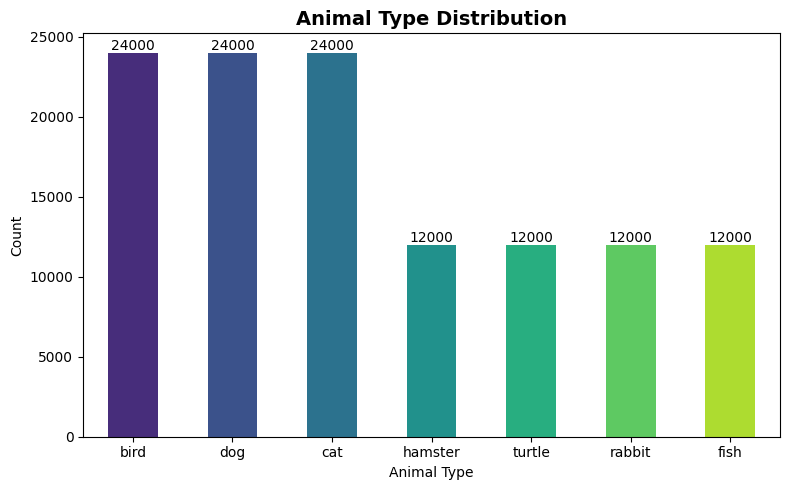

In [14]:
plt.figure(figsize=(8, 5))

ax = dataset['animal_type'].value_counts().plot(
    kind='bar', color=sns.color_palette('viridis', dataset['animal_type'].nunique())
)

plt.title("Animal Type Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Animal Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
ax.bar_label(ax.containers[0])
plt.tight_layout()

plt.show()

### 5.2 Breed distribution

In [15]:
breed_counts = dataset['breed'].value_counts()
breed_counts.head()

breed
Button Quail         1200
Pionus Parrot        1200
Cockatoo             1200
Poodle               1200
British Shorthair    1200
Name: count, dtype: int64

Summary statistics on how often each breed appears:

In [16]:
breed_counts.describe()

count     100.0
mean     1200.0
std         0.0
min      1200.0
25%      1200.0
50%      1200.0
75%      1200.0
max      1200.0
Name: count, dtype: float64

### 5.3 Housing type distribution

In [17]:
dataset['housing_type'].value_counts()

housing_type
house        55815
apartment    51674
farm         12511
Name: count, dtype: int64

Count of pets by housing type:

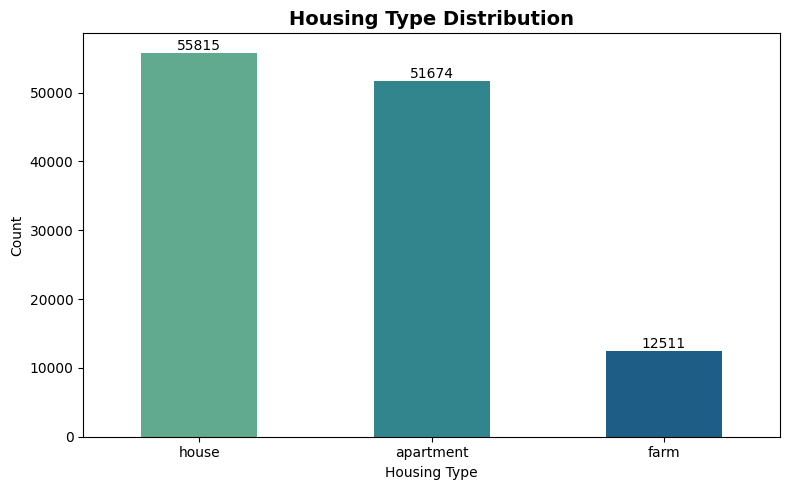

In [18]:
plt.figure(figsize=(8, 5))

ax = dataset['housing_type'].value_counts().plot(
    kind='bar', color=sns.color_palette('crest', dataset['housing_type'].nunique())
)

plt.title("Housing Type Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Housing Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
ax.bar_label(ax.containers[0])
plt.tight_layout()

plt.show()

### 5.4 Family type

In [19]:
dataset['family_type'].value_counts()

family_type
family_with_children    59902
couple                  36194
alone                   23904
Name: count, dtype: int64

### 5.5 Experience level

In [20]:
dataset['experience_level'].value_counts()

experience_level
beginner        56555
intermediate    35250
expert          28195
Name: count, dtype: int64

### 5.6 Activity level

In [21]:
dataset['activity_level'].value_counts()

activity_level
high      43158
medium    41441
low       35401
Name: count, dtype: int64

### 5.7 Budget level

In [22]:
dataset['budget_level'].value_counts()

budget_level
medium    48408
low       39598
high      31994
Name: count, dtype: int64

### 5.8 Cross-tabulation analysis

`pd.crosstab` is used to study the relationship between two categorical variables, which helps understand how household circumstances relate to the recommended breed.

**Animal type vs. housing type**

In [23]:
pd.crosstab(dataset['animal_type'],
            dataset['housing_type'])

housing_type,apartment,farm,house
animal_type,,,
bird,9660,2382,11958
cat,13318,1247,9435
dog,7883,4612,11505
fish,6028,588,5384
hamster,6025,544,5431
rabbit,4784,1181,6035
turtle,3976,1957,6067


**Breed vs. experience level**

In [24]:
pd.crosstab(dataset['breed'],
            dataset['experience_level'])

experience_level,beginner,expert,intermediate
breed,,,
Abyssinian,109,102,989
African Grey Parrot,113,975,112
Albino Syrian Hamster,1007,80,113
Amazon Parrot,120,954,126
American Shorthair,984,107,109
...,...,...,...
Turkish Angora,103,125,972
Winter White Dwarf Hamster,995,94,111
Yorkshire Terrier,1011,90,99


**Breed vs. budget level**

In [25]:
pd.crosstab(dataset['breed'],
            dataset['budget_level'])

budget_level,high,low,medium
breed,,,
Abyssinian,108,98,994
African Grey Parrot,984,104,112
Albino Syrian Hamster,111,979,110
Amazon Parrot,992,103,105
American Shorthair,112,990,98
...,...,...,...
Turkish Angora,105,110,985
Winter White Dwarf Hamster,121,958,121
Yorkshire Terrier,97,97,1006
